### set up

In [184]:
import numpy as np
from numpy import trapezoid
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from astropy.io import fits
import astropy.units as u
from astropy.visualization import ZScaleInterval
import os

In [185]:
formatter = ScalarFormatter(useOffset=False)

### read in SRT data file & data cube (Q1)

In [186]:
# srt data

input_file = ('drive/MyDrive/astro465/lab4/data4/radio2_data_lauren.rad')
output_file = ('drive/MyDrive/astro465/lab4/data4/processed_lab4_data.rad')

with open(input_file, 'r') as infile, open(output_file, 'w') as outfile:
    for line in infile:
        if not line.startswith('*'):
            line_proc = ','.join(line.split())
            outfile.write(line_proc + '\n')
        else:
            outfile.write(line)

data = pd.read_csv(output_file,
                   sep=',',
                   comment='*',
                   header=None,
                   names=['time', 'az', 'el', 'az_offset', 'el_offset',
                          'freq_1_bin', 'channel_width', 'spectrometer_mode',
                          'num_channels'] + [f'freq_channel_{i+1}' for i in range(156)])


In [187]:
# data cube

file = ('drive/MyDrive/astro465/lab4/data4/LDSfull.fits')
cube = fits.open(file)
cube_data = cube[0].data
cube_data.shape

(389, 361, 720)

### data exploration

In [188]:
data_cal = data[:8]
data = data[8:]

In [189]:
data_cal.shape, data.shape

((8, 165), (113, 165))

In [190]:
data_cal

,time,az,el,az_offset,el_offset,freq_1_bin,channel_width,spectrometer_mode,num_channels,freq_channel_1,...,freq_channel_147,freq_channel_148,freq_channel_149,freq_channel_150,freq_channel_151,freq_channel_152,freq_channel_153,freq_channel_154,freq_channel_155,freq_channel_156
0,2025:308:22:51:42,0.0,0.0,0.0,0.0,1419.75,0.007812,1,64,371.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025:308:22:51:50,0.0,0.0,0.0,0.0,1419.79,0.007812,4,156,405.2,...,18788.1,18126.1,18488.5,12142.6,9346.6,5929.7,3347.7,1662.7,826.7,435.8
2,2025:308:22:53:55,42.1,56.7,0.0,0.0,1419.79,0.007812,4,156,94.5,...,16519.6,16721.5,16768.0,11483.2,8339.8,5411.4,3327.0,1808.6,994.2,673.9
3,2025:308:22:54:54,41.9,86.8,0.0,30.0,1419.79,0.007812,4,156,80.7,...,17103.3,16323.7,16500.1,11536.0,8350.0,5491.1,3288.1,1807.1,1001.2,685.2
4,2025:308:22:55:02,41.9,86.8,0.0,30.0,1419.79,0.007812,4,156,435.2,...,16962.2,17405.8,17441.4,12157.6,8485.0,5422.5,3137.0,1569.4,723.9,372.3
5,2025:308:22:55:10,41.9,86.8,0.0,30.0,1419.79,0.007812,4,156,446.9,...,16574.4,16359.5,16794.4,11373.7,8172.3,5147.9,2936.5,1456.2,677.8,349.4
6,2025:308:22:55:19,41.9,86.9,0.0,30.0,1419.79,0.007812,4,156,39.5,...,2431.4,2421.3,2452.9,1684.6,1215.1,802.4,454.5,239.5,125.1,72.5
7,2025:308:22:56:14,41.9,57.0,0.0,0.0,1419.79,0.007812,4,156,15.5,...,2505.8,2495.7,2426.2,1698.5,1237.2,806.4,485.4,268.0,152.9,100.5


In [191]:
data.head(10)

,time,az,el,az_offset,el_offset,freq_1_bin,channel_width,spectrometer_mode,num_channels,freq_channel_1,...,freq_channel_147,freq_channel_148,freq_channel_149,freq_channel_150,freq_channel_151,freq_channel_152,freq_channel_153,freq_channel_154,freq_channel_155,freq_channel_156
8,2025:308:22:56:22,41.9,57.0,0.0,0.0,1419.79,0.007812,4,156,30.6,...,2506.5,2469.3,2476.1,1669.1,1217.5,786.8,468.9,252.2,134.9,86.1
9,2025:308:22:56:30,41.9,57.0,0.0,0.0,1419.79,0.007812,4,156,78.0,...,2485.6,2387.7,2461.6,1677.2,1201.3,791.0,423.7,209.3,86.0,36.4
10,2025:308:22:56:38,41.9,57.0,0.0,0.0,1419.79,0.007812,4,156,36.7,...,2510.7,2465.5,2479.1,1752.2,1232.7,790.5,462.2,247.3,129.6,79.4
11,2025:308:22:56:47,41.9,57.1,0.0,0.0,1419.79,0.007812,4,156,-20.9,...,2496.9,2489.7,2523.5,1770.6,1320.6,850.5,512.3,294.8,179.7,134.5
12,2025:308:22:56:55,41.9,57.1,0.0,0.0,1419.79,0.007812,4,156,38.7,...,2468.2,2470.9,2429.4,1703.3,1224.4,789.8,455.9,246.6,124.7,76.6
13,2025:308:22:57:02,41.9,57.1,0.0,0.0,1419.79,0.007812,4,156,5.2,...,2430.5,2507.0,2528.3,1694.4,1275.7,844.9,487.0,269.9,157.4,106.9
14,2025:308:22:57:10,41.9,57.1,0.0,0.0,1419.79,0.007812,4,156,31.5,...,2445.0,2472.9,2506.2,1702.9,1215.2,807.0,448.4,255.3,131.4,84.1
15,2025:308:22:57:18,41.9,57.1,0.0,0.0,1419.79,0.007812,4,156,44.3,...,2430.5,2418.6,2500.7,1647.9,1221.8,785.5,454.2,236.6,120.7,69.3
16,2025:308:22:57:26,41.9,57.1,0.0,0.0,1419.79,0.007812,4,156,9.6,...,2409.2,2516.3,2427.2,1725.5,1215.6,834.7,473.5,272.1,154.7,104.2
17,2025:308:22:57:34,41.9,57.1,0.0,0.0,1419.79,0.007812,4,156,55.3,...,2476.5,2433.2,2382.1,1692.8,1178.0,778.9,445.0,226.2,110.6,62.0


based on this line from the .rad file:

* `tsys  2412 calcons 0.15 trecvr 2392 tload  103 tspill   20`

the system temperature is 2412 K

In [192]:
CALCONS = 0.15

In [193]:
data['el'].mean()

np.float64(57.922123893805306)

### produce the averaged HI spectrum (Q2)

Average all HI spectra at your selected position in the Galactic plane. The average HI spectrum is in units of antenna temperature. Using information in your observing data file, calculate the frequency array that will be plotted on the x-axis. Make a plot of your averaged HI spectrum as a function of frequency.

In [194]:
spectral_columns = [col for col in data.columns if col.startswith('freq_channel_')]

In [195]:
# calculate average for each frequency channel

average_HI_spectra = data[spectral_columns].mean(axis=0)
average_HI_spectra

,0
freq_channel_1,30.982301
freq_channel_2,43.649558
freq_channel_3,91.687611
freq_channel_4,204.598230
freq_channel_5,413.054867
...,...
freq_channel_152,803.801770
freq_channel_153,468.252212
freq_channel_154,249.884071
freq_channel_155,132.922124


In [196]:
# create frequency array

freq_1 = 1419.79
width = 0.0078125

freq_array = freq_1 + np.arange(156) * width
freq_array

array([1419.79     , 1419.7978125, 1419.805625 , 1419.8134375,
       1419.82125  , 1419.8290625, 1419.836875 , 1419.8446875,
       1419.8525   , 1419.8603125, 1419.868125 , 1419.8759375,
       1419.88375  , 1419.8915625, 1419.899375 , 1419.9071875,
       1419.915    , 1419.9228125, 1419.930625 , 1419.9384375,
       1419.94625  , 1419.9540625, 1419.961875 , 1419.9696875,
       1419.9775   , 1419.9853125, 1419.993125 , 1420.0009375,
       1420.00875  , 1420.0165625, 1420.024375 , 1420.0321875,
       1420.04     , 1420.0478125, 1420.055625 , 1420.0634375,
       1420.07125  , 1420.0790625, 1420.086875 , 1420.0946875,
       1420.1025   , 1420.1103125, 1420.118125 , 1420.1259375,
       1420.13375  , 1420.1415625, 1420.149375 , 1420.1571875,
       1420.165    , 1420.1728125, 1420.180625 , 1420.1884375,
       1420.19625  , 1420.2040625, 1420.211875 , 1420.2196875,
       1420.2275   , 1420.2353125, 1420.243125 , 1420.2509375,
       1420.25875  , 1420.2665625, 1420.274375 , 1420.2

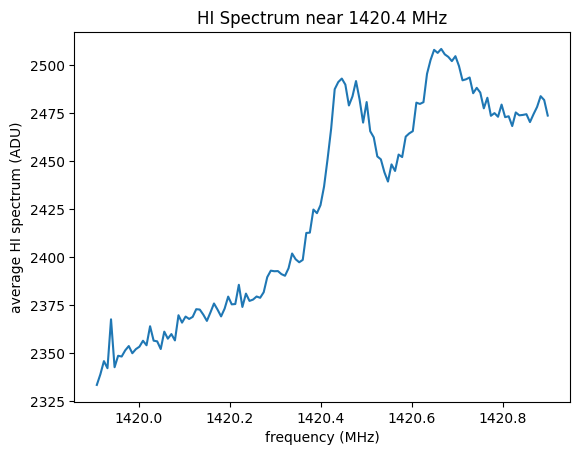

In [197]:
mask=(freq_array>1419.9) & (freq_array<1420.9)
x=freq_array[mask]
y=average_HI_spectra[mask]
plt.plot(x,y)
plt.xlabel('frequency (MHz)')
plt.ylabel('average HI spectrum (ADU)')
plt.title('HI Spectrum near 1420.4 MHz')
ax = plt.gca()
ax.xaxis.set_major_formatter(formatter)
plt.show()

In [15]:
# plt.plot(freq_array, data[spectral_columns].iloc[0])

Use the non-relativistic Doppler shift equation to convert frequency into Topocentric Radial Velocity. Make a plot of the Antenna Temperature vs. Topocentric Radial Velocity.
$$v_r \cong \frac{c(v_0 - v)}{v}$$
where c is the speed of light, $v_0$ is the rest frequency (in our case, frequency of the 21 cm line of atomic hydrogen), and $v$ is the observed frequency in our data

In [198]:
# convert freq to radial velocity

c = 299792  # km/s
v0 = 1420.4 # MHz

radial_velocity = c * (v0-freq_array)/freq_array
radial_velocity

array([ 128.80293565,  127.15260822,  125.50229895,  123.85200785,
        122.2017349 ,  120.55148012,  118.9012435 ,  117.25102504,
        115.60082473,  113.95064259,  112.30047861,  110.65033279,
        109.00020512,  107.35009562,  105.70000427,  104.04993108,
        102.39987605,  100.74983917,   99.09982046,   97.4498199 ,
         95.79983749,   94.14987325,   92.49992715,   90.84999922,
         89.20008944,   87.55019781,   85.90032434,   84.25046902,
         82.60063186,   80.95081285,   79.301012  ,   77.6512293 ,
         76.00146475,   74.35171835,   72.70199011,   71.05228001,
         69.40258807,   67.75291429,   66.10325865,   64.45362116,
         62.80400182,   61.15440064,   59.5048176 ,   57.85525271,
         56.20570598,   54.55617739,   52.90666695,   51.25717466,
         49.60770051,   47.95824452,   46.30880667,   44.65938697,
         43.00998542,   41.36060201,   39.71123675,   38.06188963,
         36.41256066,   34.76324984,   33.11395716,   31.46468

In [199]:
antenna_temp = average_HI_spectra * CALCONS

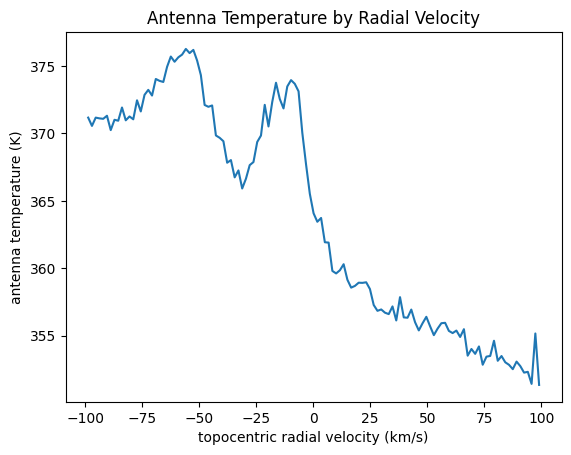

In [77]:
mask=(radial_velocity>-100) & (radial_velocity<100)
x=radial_velocity[mask]
y=antenna_temp[mask]
plt.plot(x,y)
plt.xlabel('topocentric radial velocity (km/s)')
plt.ylabel('antenna temperature (K)')
plt.title('Antenna Temperature by Radial Velocity')
plt.show()

Perform a linear polynomial fit to frequency channels with no obvious HI emission to model the spectral baseline; subtract the baseline from your spectrum. Make a plot of the baseline subtracted averaged HI spectrum as a function of Topocentric radio velocity.

### fixed basline subtraction

In [200]:
# Good starting choices for your data (based on the plot you sent):
v_start_1, v_end_1 = -100, -90   # left plateau window
v_start_2, v_end_2 = 90, 100     # right plateau window

mask1 = (radial_velocity >= v_start_1) & (radial_velocity <= v_end_1)
mask2 = (radial_velocity >= v_start_2) & (radial_velocity <= v_end_2)
line_free_mask = mask1 | mask2

print("Selected velocity windows:", (v_start_1, v_end_1), (v_start_2, v_end_2))
print("Number of line-free points:", np.count_nonzero(line_free_mask))

if np.count_nonzero(line_free_mask) < 6:
    print("WARNING: only a few points selected for the baseline. Expand the windows slightly.")


Selected velocity windows: (-100, -90) (90, 100)
Number of line-free points: 12


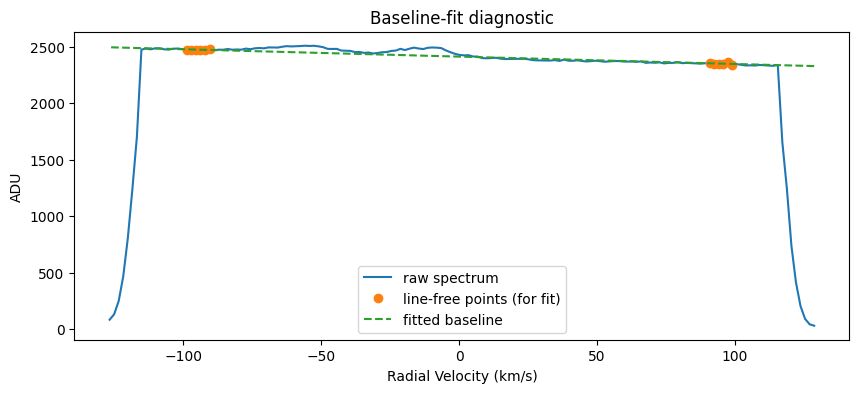

In [201]:
# Get points used for fit
lf_vel = radial_velocity[line_free_mask]
lf_adu = average_HI_spectra[line_free_mask]

# Fit a 1st-order baseline
p = np.polyfit(lf_vel, lf_adu, 1)
baseline_fit = np.polyval(p, radial_velocity)

# Diagnostic plot: show which points were used and the fit
plt.figure(figsize=(10,4))
plt.plot(radial_velocity, average_HI_spectra, label='raw spectrum')
plt.plot(lf_vel, lf_adu, 'o', label='line-free points (for fit)')
plt.plot(radial_velocity, baseline_fit, '--', label='fitted baseline')
plt.xlabel('Radial Velocity (km/s)')
plt.ylabel('ADU')
plt.legend()
plt.title('Baseline-fit diagnostic')
plt.show()

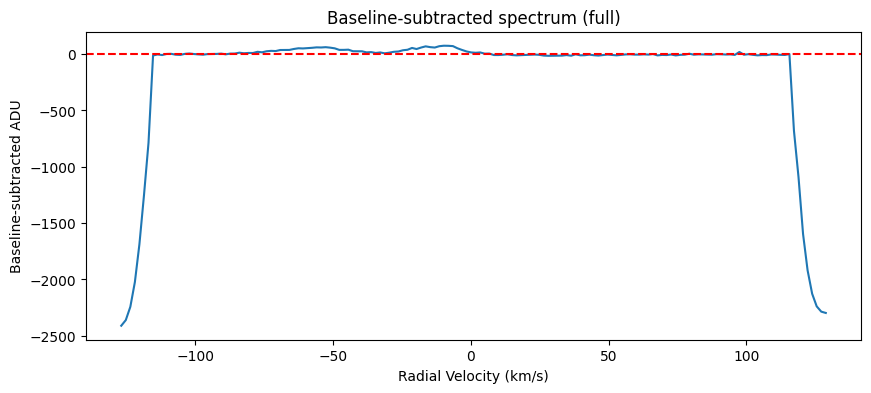

In [202]:
# Subtract & show final
baseline_subtracted = average_HI_spectra - baseline_fit
plt.figure(figsize=(10,4))
plt.plot(radial_velocity, baseline_subtracted, label='baseline-subtracted')
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Radial Velocity (km/s)')
plt.ylabel('Baseline-subtracted ADU')
plt.title('Baseline-subtracted spectrum (full)')
plt.show()

In [203]:
mask_srt = (radial_velocity >= -100) & (radial_velocity <= 100)
mask_lds = (velocity >= -100) & (velocity <= 100)

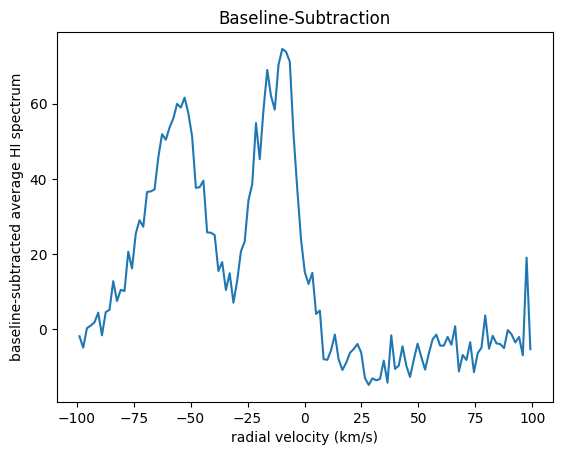

In [204]:
plt.plot(radial_velocity[mask_srt], baseline_subtracted[mask_srt], label='baseline-subtracted')
plt.xlabel('radial velocity (km/s)')
plt.ylabel('baseline-subtracted average HI spectrum')
plt.title('Baseline-Subtraction')
plt.show()

### baseline subtraction: antenna temperature

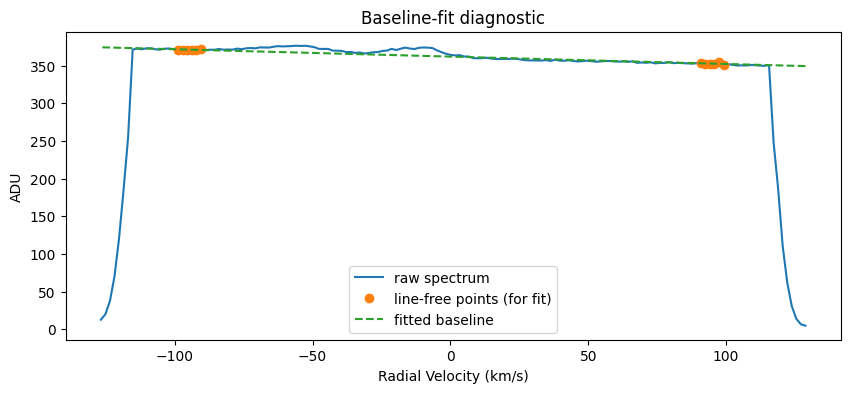

In [218]:
# Get points used for fit
lf_vel = radial_velocity[line_free_mask]
lf_adu_TA = antenna_temp[line_free_mask]

# Fit a 1st-order baseline
p_TA = np.polyfit(lf_vel, lf_adu_TA, 1)
baseline_fit_TA = np.polyval(p_TA, radial_velocity)

# Diagnostic plot: show which points were used and the fit
plt.figure(figsize=(10,4))
plt.plot(radial_velocity, antenna_temp, label='raw spectrum')
plt.plot(lf_vel, lf_adu, 'o', label='line-free points (for fit)')
plt.plot(radial_velocity, baseline_fit, '--', label='fitted baseline')
plt.xlabel('Radial Velocity (km/s)')
plt.ylabel('ADU')
plt.legend()
plt.title('Baseline-fit diagnostic')
plt.show()

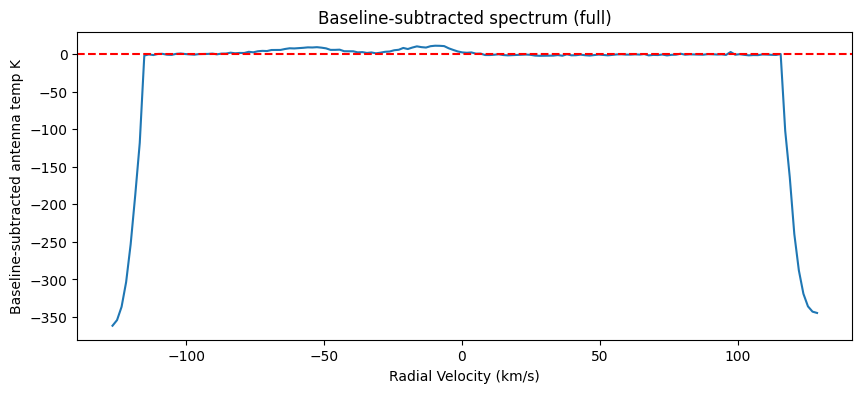

In [219]:
# Subtract & show final
baseline_subtracted_TA = antenna_temp - baseline_fit_TA
plt.figure(figsize=(10,4))
plt.plot(radial_velocity, baseline_subtracted_TA, label='baseline-subtracted')
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Radial Velocity (km/s)')
plt.ylabel('Baseline-subtracted antenna temp K')
plt.title('Baseline-subtracted spectrum (full)')
plt.show()

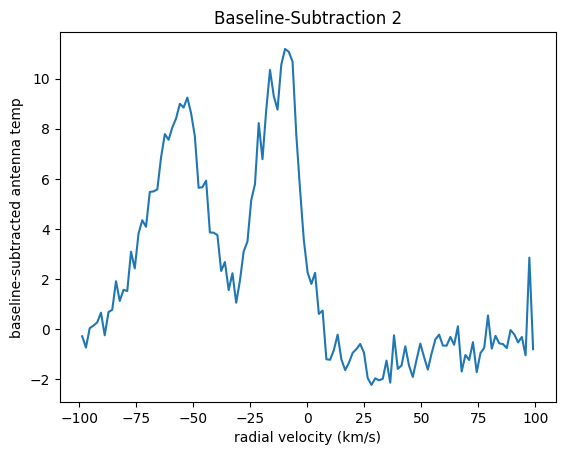

In [220]:
plt.plot(radial_velocity[mask_srt], baseline_subtracted_TA[mask_srt], label='baseline-subtracted')
plt.xlabel('radial velocity (km/s)')
plt.ylabel('baseline-subtracted antenna temp')
plt.title('Baseline-Subtraction 2')
plt.show()

### extract corresponding HI spectrum from LDS survey (Q3)

Access the LDS FITS data cube and locate the position of your observations. As LDS has a higher angular resolution than our SRT, to compare spectra at the same resolution, average 12 x 12 LDS spectra around your selected position. Make a plot, this will show HI Brightness temperature as a function of Radial Velocity.

for galactic coordinates ($\ell$, $b$) = (110, 0):

in plane coordinates ($x, y$) = (220, 180)

In [113]:
cube_data.shape

(389, 361, 720)

In [56]:
header = cube[0].header
header

SIMPLE  =                    T / Written by IDL:  Mon Mar 26 16:12:26 2012      
BITPIX  =                  -64 / Number of bits per data pixel                  
NAXIS   =                    3 / Number of data axes                            
NAXIS1  =                  720 /                                                
NAXIS2  =                  361 /                                                
NAXIS3  =                  389 /                                                
CRVAL1  =              180.000 /                                                
CRPIX1  =              361.000 /                                                
CDELT1  =             0.500000 /                                                
CTYPE1  = 'GLON-CAR'           /                                                
CRVAL2  =              0.00000 /                                                
CRPIX2  =              181.000 /                                                
CDELT2  =             0.5000

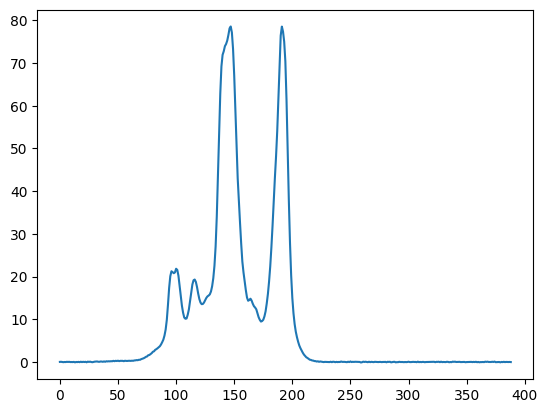

In [114]:
# [velocity, y, x]
spectrum = cube_data[:, 180, 220]
plt.plot(spectrum)

In [115]:
velocity_center = header["CRVAL3"]/1000
velocity_inc = header["CDELT3"]/1000
velocity_pix = header["CRPIX3"]

channels = np.arange(len(spectrum))

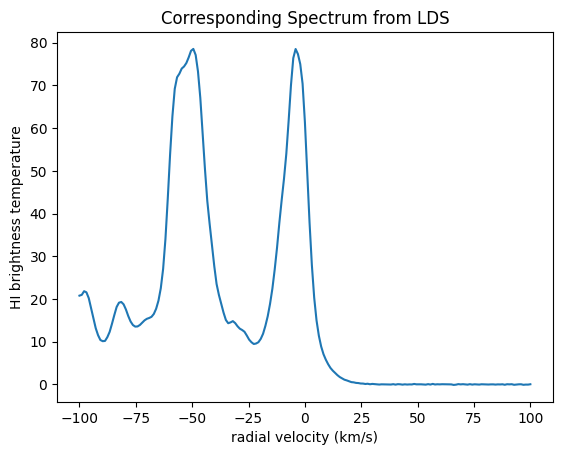

In [205]:
velocity = velocity_center + velocity_inc * (channels-velocity_pix)
velocity = np.array(velocity, dtype=float)
plt.plot(velocity[mask_lds], spectrum[mask_lds])
plt.xlabel('radial velocity (km/s)')
plt.ylabel('HI brightness temperature')
plt.title('Corresponding Spectrum from LDS')
plt.show()

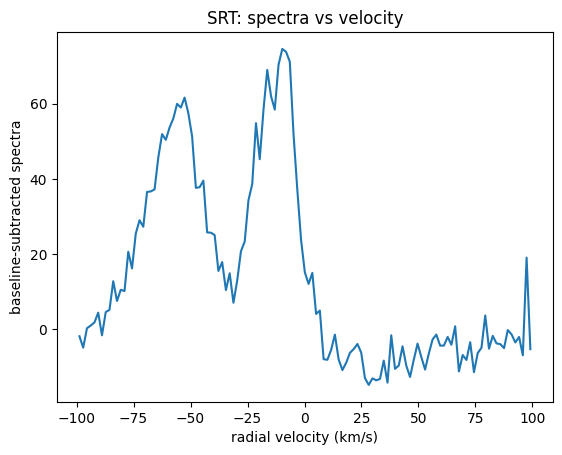

In [127]:
mask_zoom = (radial_velocity >= -100) & (radial_velocity <= 100)
plt.plot(radial_velocity[mask_zoom], baseline_subtracted[mask_zoom])
plt.xlabel('radial velocity (km/s)')
plt.ylabel('baseline-subtracted spectra')
plt.title('SRT: spectra vs velocity')
plt.show()

#### main beam efficiency

In [206]:
ix, iy = 220, 180
subcube = cube_data[:, iy-6:iy+6, ix-6:ix+6]
avg_lds_spectrum = np.nanmean(subcube, axis=(1,2))

In [222]:
# --- LDS spectrum (in K)
integrated_intensity_lds_K = trapezoid(spectrum, velocity)
print(f"LDS Integrated Intensity: {integrated_intensity_lds_K:.2f} K km/s")

# --- SRT spectrum (convert ADU → K using CALCONS *before* integrating)
integrated_intensity_srt_K = trapezoid(baseline_subtracted * CALCONS, radial_velocity)
print(f"SRT Integrated Intensity: {integrated_intensity_srt_K:.2f} K km/s")


LDS Integrated Intensity: 3602.00 K km/s
SRT Integrated Intensity: 5702.08 K km/s


In [208]:
# --- Compute main beam efficiency (scaling factor)
main_beam_efficiency = integrated_intensity_lds_K / integrated_intensity_srt_K
print(f"Main Beam Efficiency: {main_beam_efficiency:.3f}")

Main Beam Efficiency: 0.632


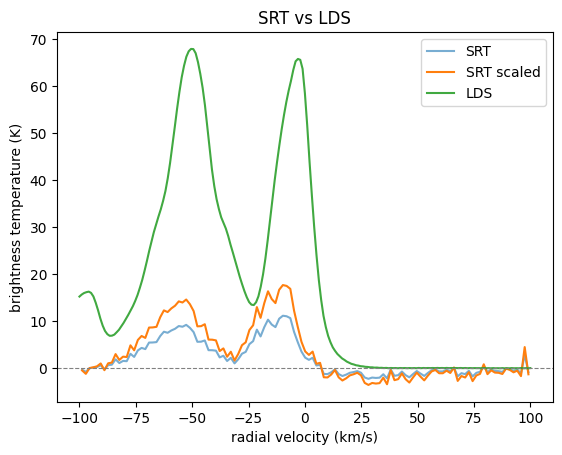

In [226]:
eta_mb = main_beam_efficiency
antenna_T = baseline_subtracted*CALCONS

plt.plot(radial_velocity[mask_srt], antenna_T[mask_srt], label='SRT', alpha=0.6)
plt.plot(radial_velocity[mask_srt], (antenna_T/eta_mb)[mask_srt], label=f'SRT scaled', color='tab:orange')
plt.plot(velocity[mask_lds], avg_lds_spectrum[mask_lds], label='LDS', color='tab:green', alpha=0.9)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('radial velocity (km/s)')
plt.ylabel('brightness temperature (K)')
plt.title('SRT vs LDS')
plt.legend()
plt.show()


### new estimate of $T_{sys}$ (Q4)

We can now use the radiometer equation to estimate Tsys.
$$\sigma_T = \frac{T_{sys}}{\sqrt{\Delta v T}}$$
where $T_{sys}$ is the system temperature in K, $T$ is the integration time in seconds, $\Delta v$ is spectral resolution in Hz, and $\sigma_T$ is the noise in the spectral-line observation in K.
Solving for $T_{sys}$, we get
$$T_{sys} = \sigma_T \cdot \sqrt{\Delta v T}$$

To estimate the total
integration time used to produce this spectrum use the following: the real integration
time is about 1/15 of the actual elapsed time during your observation (yes, the SRTs
take a lot of time to write data and the real observing time is far less than what we
requested!).

In [227]:
# total integration time
# T = 900/15
T = 900

The bandwidth of a single frequency channel is 0.0078125 MHz.

In [228]:
channel_width_hz = width * 1000000
channel_width_hz

7812.5

For a range of frequency
channels away from the HI peak which look essentially like noise only, measure the
rms noise of your baseline-subtracted average HI spectrum.

In [229]:
rms_noise_ADU = np.std(baseline_subtracted[line_free_mask])
rms_noise_K = rms_noise_ADU*CALCONS
print("RMS noise [K] =", rms_noise_K)

RMS noise [K] = 0.9777124735856054


In [230]:
Tsys = rms_noise_K * np.sqrt(channel_width_hz * 900)
print("Tsys =", Tsys)

Tsys = 2592.5517004614553
